# CNN_Trash_Classification - Deteksi Semua Jenis Sampah

Notebook sederhana untuk mendeteksi semua jenis sampah di TrashType:
- cardboard
- glass
- metal
- paper
- plastic
- trash

In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
print('✓ Library siap')
print(f'TensorFlow version: {tf.__version__}')

✓ Library siap
TensorFlow version: 2.21.0


## STEP 1: Load Dataset - Semua Kelas Sampah

In [10]:
DATA_DIR = 'TrashType_Image_Dataset'
IMG_SIZE = (64, 64)

# Baca semua kelas dari folder
CLASS_NAMES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Kelas sampah: {CLASS_NAMES}')
print(f'Total kelas: {NUM_CLASSES}')

# Kumpulkan semua gambar dari setiap kelas
paths = []
labels = []

for label, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            paths.append(os.path.join(cls_dir, fname))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print(f'\nTotal gambar: {len(paths)}')
for i, cls in enumerate(CLASS_NAMES):
    count = np.sum(labels == i)
    print(f'  {cls}: {count} gambar')

Kelas sampah: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total kelas: 6

Total gambar: 2527
  cardboard: 403 gambar
  glass: 501 gambar
  metal: 410 gambar
  paper: 594 gambar
  plastic: 482 gambar
  trash: 137 gambar


## STEP 2: Split Data dan Load Gambar

In [11]:
# Split: 70% train, 15% val, 15% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print('Pembagian data:')
print(f'  Training:   {len(train_paths)} gambar (70%)')
print(f'  Validation: {len(val_paths)} gambar (15%)')
print(f'  Testing:    {len(test_paths)} gambar (15%)')

def load_images(path_list):
    """Load gambar dari disk ke memory"""
    images = []
    for path in path_list:
        try:
            img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
            img = tf.keras.utils.img_to_array(img)
            images.append(img)
        except:
            continue
    return np.array(images, dtype='float32')

print('\nLoading images ke memory...')
X_train = load_images(train_paths)
X_val = load_images(val_paths)
X_test = load_images(test_paths)

# Normalisasi: 0-255 -> 0-1
X_train /= 255.0
X_val /= 255.0
X_test /= 255.0

# Convert labels to one-hot encoding (untuk multi-class)
y_train = tf.keras.utils.to_categorical(train_labels, NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(val_labels, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(test_labels, NUM_CLASSES)

print('\nShape data:')
print(f'  X_train: {X_train.shape}')
print(f'  X_val:   {X_val.shape}')
print(f'  X_test:  {X_test.shape}')

Pembagian data:
  Training:   1768 gambar (70%)
  Validation: 379 gambar (15%)
  Testing:    380 gambar (15%)

Loading images ke memory...

Shape data:
  X_train: (1768, 64, 64, 3)
  X_val:   (379, 64, 64, 3)
  X_test:  (380, 64, 64, 3)


## STEP 3: Buat Model CNN

In [12]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    # Output: 6 kelas sampah
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Struktur Model:')
model.summary()

Struktur Model:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## STEP 4: Training Model

In [13]:
EPOCHS = 20
BATCH_SIZE = 32

print(f'Training selama {EPOCHS} epoch...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
print('✓ Training selesai!')

Training selama 20 epoch...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.3456 - loss: 1.5631 - val_accuracy: 0.4670 - val_loss: 1.3541
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.4655 - loss: 1.3361 - val_accuracy: 0.4828 - val_loss: 1.2602
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.5379 - loss: 1.2013 - val_accuracy: 0.5488 - val_loss: 1.2097
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.5707 - loss: 1.1380 - val_accuracy: 0.5989 - val_loss: 1.1229
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.6052 - loss: 1.0274 - val_accuracy: 0.6359 - val_loss: 1.0206
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.6674 - loss: 0.9198 - val_accuracy: 0.6148 - val_loss: 1.0721
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.6646 - loss: 0.8655 - val_accuracy: 0.5778 - val_loss: 1.0816
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.7059 - 

## STEP 5: Evaluasi Model

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test Loss: {test_loss:.4f}')

# Prediksi pada test set
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Test Accuracy: 0.6632 (66.32%)
Test Loss: 1.2224

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   cardboard       0.80      0.73      0.77        60
       glass       0.61      0.57      0.59        76
       metal       0.65      0.55      0.60        62
       paper       0.66      0.88      0.75        89
     plastic       0.64      0.56      0.60        73
       trash       0.63      0.60      0.62        20

    accuracy                           0.66       380
   macro avg       0.66      0.65      0.65       380
weighted avg       0.66      0.66      0.66       380



## STEP 6: Confusion Matrix

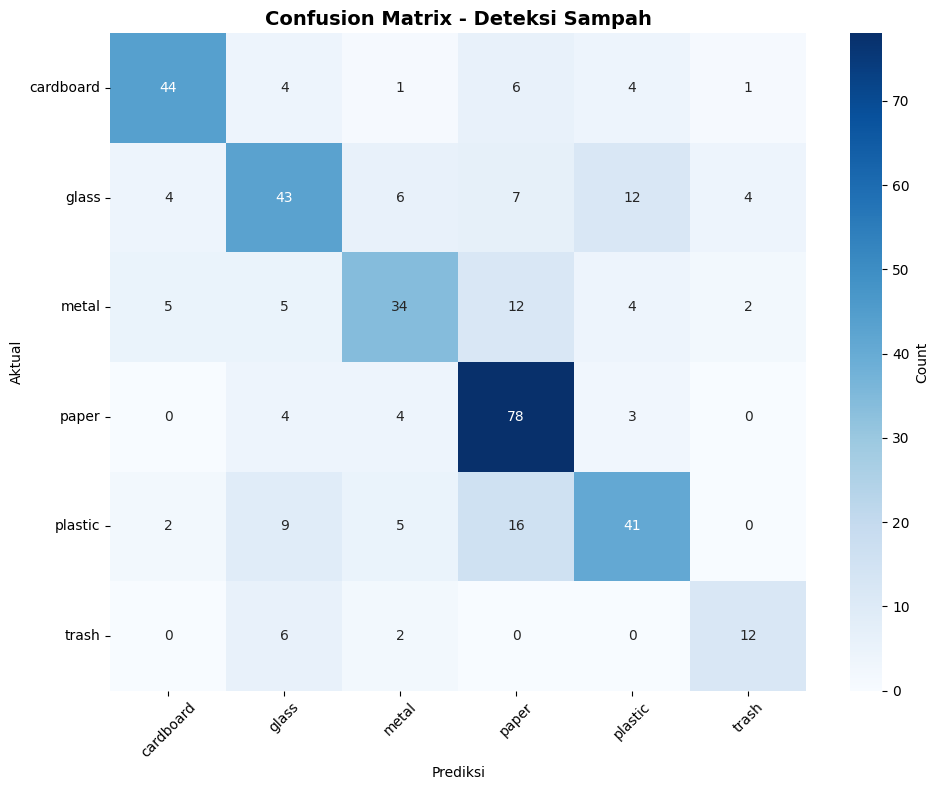

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Deteksi Sampah', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## STEP 7: Visualisasi Training History

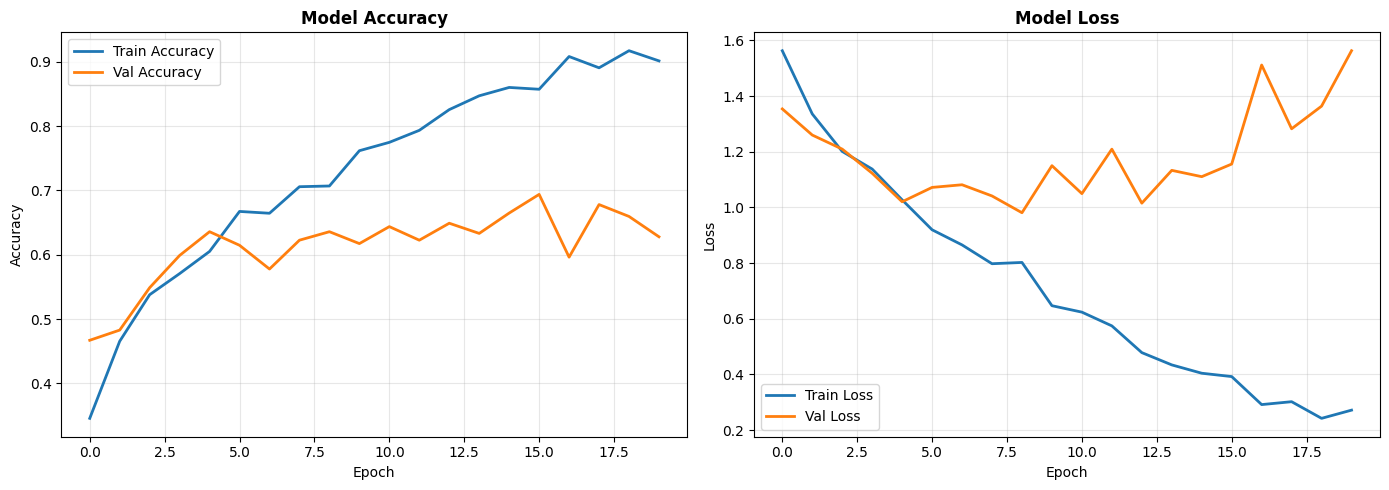

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## STEP 8: Prediksi Sampel Gambar

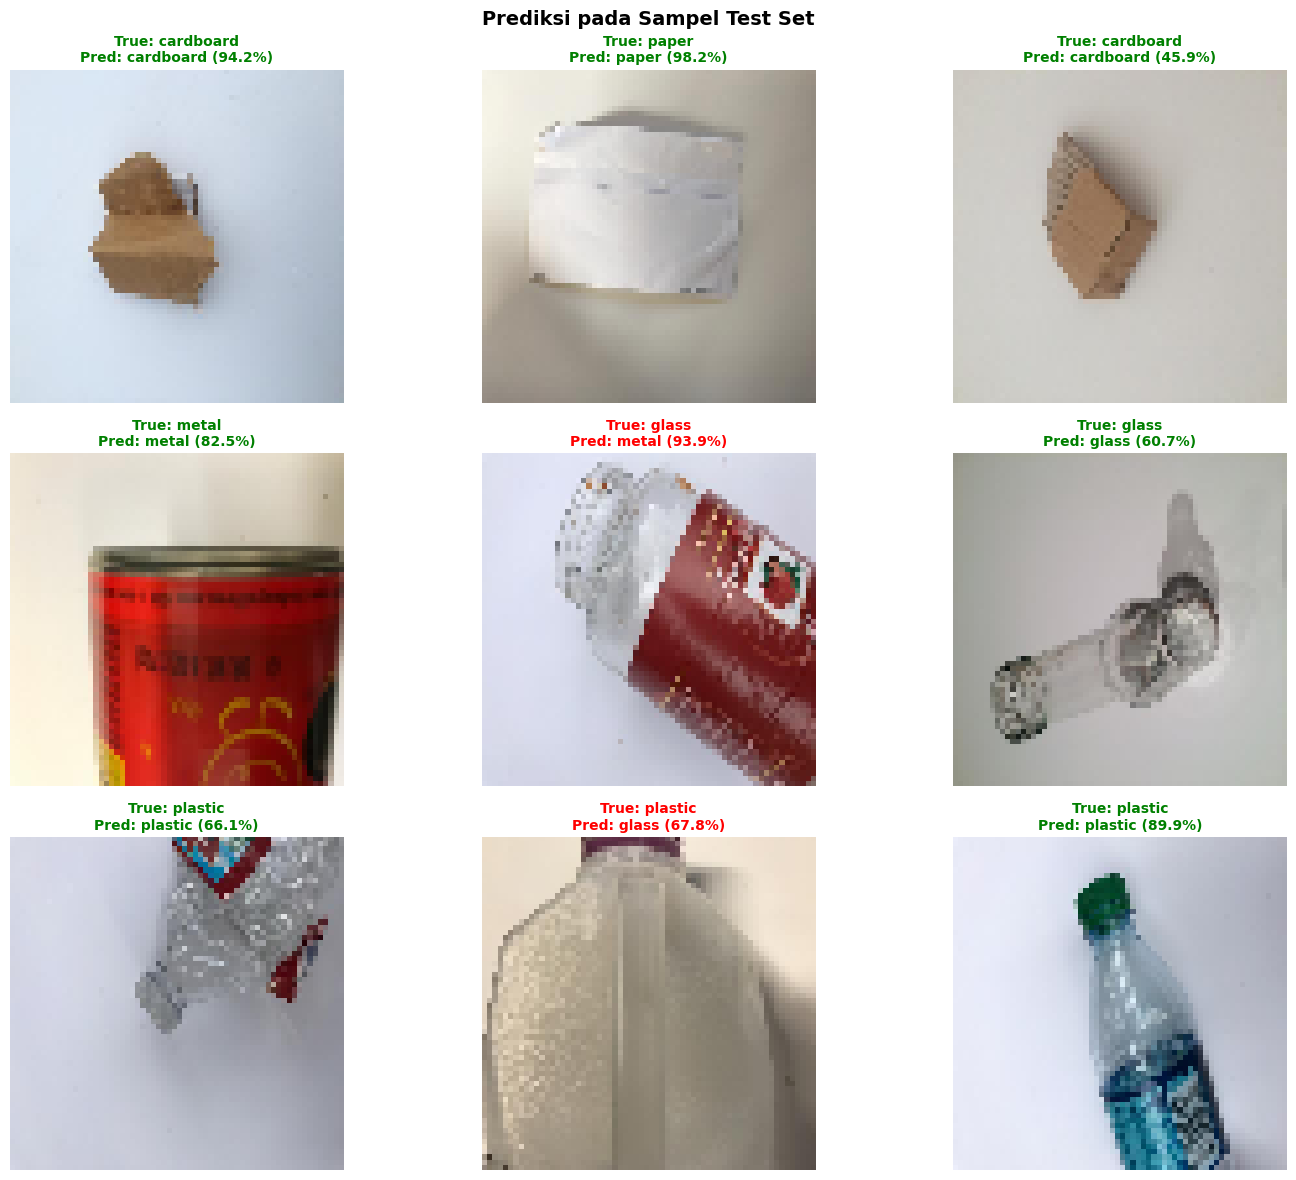

In [17]:
# Ambil 9 gambar random dari test set
num_samples = 9
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, sample_idx in enumerate(random_indices):
    img = X_test[sample_idx]
    true_label = CLASS_NAMES[y_true[sample_idx]]
    
    # Prediksi
    pred_prob = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_label = CLASS_NAMES[np.argmax(pred_prob)]
    confidence = np.max(pred_prob) * 100
    
    # Warna: hijau jika benar, merah jika salah
    color = 'green' if true_label == pred_label else 'red'
    
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(
        f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
        color=color, fontweight='bold', fontsize=10
    )

plt.suptitle('Prediksi pada Sampel Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9: Probabilitas Detail Satu Gambar

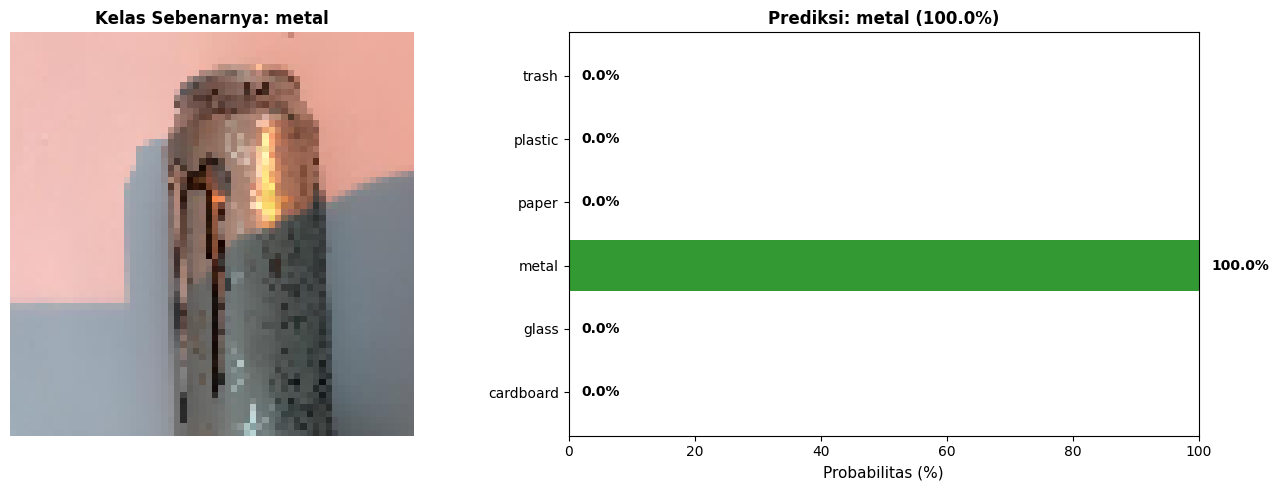

In [18]:
# Pilih 1 gambar random
sample_idx = np.random.randint(0, len(X_test))
sample_img = X_test[sample_idx]
true_label = CLASS_NAMES[y_true[sample_idx]]

# Prediksi
probs = model.predict(np.expand_dims(sample_img, axis=0), verbose=0)[0]
pred_idx = np.argmax(probs)
pred_label = CLASS_NAMES[pred_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gambar
axes[0].imshow(sample_img)
axes[0].set_title(f'Kelas Sebenarnya: {true_label}', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Probabilitas
colors = ['green' if cls == pred_label else 'lightgray' for cls in CLASS_NAMES]
bars = axes[1].barh(CLASS_NAMES, probs * 100, color=colors, alpha=0.8)
axes[1].set_xlabel('Probabilitas (%)', fontsize=11)
axes[1].set_title(f'Prediksi: {pred_label} ({probs[pred_idx]*100:.1f}%)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 100)

# Tambah value labels
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 2, bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()